In [1]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P/behavior'])
from timestamps import get_trial_times,get_timestamps,get_tone_frame_vector
from running import get_rest_array,load_position,calc_velocity,thr_velocity
from scipy.stats import zscore
import numpy as np
import seaborn as sb
from matplotlib import rcParams
import os
import pandas as pd
import pingouin as pg
plt.style.use('paper_style.mplstyle')
savepath='/Users/amonast/Documents/GitHub/Engram_2P/Amy_2P/analysis/tone/plots'

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
animals = ['997B','639N', 'M2L','M1N','F5L','F7N','M8BL2','194L','M5L','939L','M9BR2']
vel_df = pd.DataFrame()
for animal in animals:
    session = 'Recall1'
    file_key = '/Users/amonast/Desktop/Tone2P/Data_info_TFC.csv'
    base_dir = '/Users/amonast/Desktop/Tone2P'

    df_1=load_position(animal,'FOV1','Recall1',file_key,base_dir)
    vt0_1= calc_velocity(df_1.position.values,df_1.frame_times.values,frame_period=df_1.frame_times.values[1]-df_1.frame_times.values[0],window_size=30)
    vt1 = thr_velocity(vt0_1)
    # plt.figure()
    mean_trials = pd.DataFrame()
    for trial in range(10):
         frame_times,on_times,off_times = get_timestamps(animal,'FOV1','Recall1',file_key,base_dir,stimulus=True)
         centered_times,inds,(onset_c,offset_c) = get_trial_times(on_times,off_times,frame_times,trial,seconds_pre=0,seconds_post=20)
         vii=vt1[(inds[0]-600):inds[0]].mean()
         vi = vt1[inds].mean()
         df=pd.DataFrame()
         df['Velocity']=[vi]+[vii]
         df['Trial']=[trial]*2
         df['Period']=['Tone','Pre-Tone']
         mean_trials=pd.concat([mean_trials,df],ignore_index=True)
     #     plt.plot(centered_times,vt1[inds],)
     #     plt.legend()
    mean_trials['Animal']=[animal]*len(mean_trials)
    vel_df=pd.concat([vel_df,mean_trials],ignore_index=True)



In [3]:
mean_all_ani=vel_df.groupby(['Animal','Period']).mean().reset_index()
pre= mean_all_ani.Velocity.loc[mean_all_ani['Period']=='Pre-Tone']
tone=mean_all_ani.Velocity.loc[mean_all_ani['Period']=='Tone']
pg.normality(mean_all_ani,group='Period',dv='Velocity')

,W,pval,normal
Period,,,
Pre-Tone,0.870563,0.078823,True
Tone,0.962049,0.796976,True


In [4]:
pg.ttest(pre,tone,paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-4.575271,10,two-sided,0.001018,"[-1.82, -0.63]",0.74822,39.886,0.610217


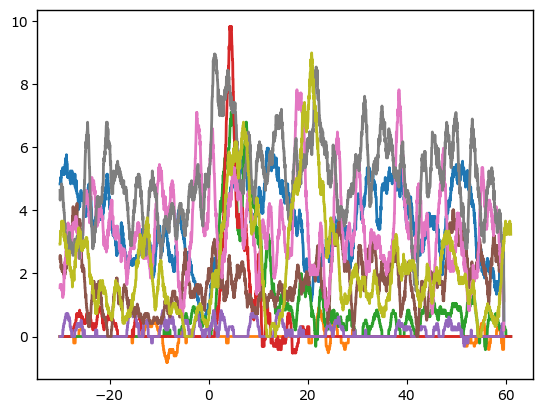

In [46]:
seconds_pre = 30
seconds_post = 60
plt.figure()
DF = pd.DataFrame()
mean_vs=[]
v_animal=[]
for animal in animals:

    df_1=load_position(animal,'FOV1','Recall1',file_key,base_dir)
    vt0_1= calc_velocity(df_1.position.values,df_1.frame_times.values,frame_period=df_1.frame_times.values[1]-df_1.frame_times.values[0],window_size=30)
    vt1 = thr_velocity(vt0_1)
    vt1 = np.array(thr_velocity(vt0_1),dtype=np.float64)
    vtz = zscore(vt1)
    trial_inds=[]
    for trial in range(10):
        frame_times,on_times,off_times = get_timestamps(animal,'FOV1','Recall1',file_key,base_dir,stimulus=True)
        centered_times,inds,(onset_c,offset_c) = get_trial_times(on_times,off_times,frame_times,trial,seconds_pre=seconds_pre,seconds_post=seconds_post)
        trial_inds.append(vt1[inds])
    lens = [x.shape[0] for x in trial_inds]
    max_len = max(lens)
    new = []
    for trial in range(10):
        if max_len>len(trial_inds[trial]):
            new.append(np.append(trial_inds[trial],0))
        else:
            new.append(trial_inds[trial])
    run_array = np.array(new)
    v_animal.append(run_array)
    vbar = run_array.mean(axis=0)
    mean_vs.append(vbar[0:897])
    df=pd.DataFrame()
    df['Mean Velocity (cm/s)']=vbar
    df['Animal']=[animal]*len(df)
    df['Time (s)']=np.arange(0,len(vbar))/30-seconds_pre
    DF = pd.concat([DF,df],ignore_index=True)
    plt.plot(np.arange(0,len(vbar))/30-seconds_pre,vbar)

all_vbar = np.array(mean_vs)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

seconds_pre = 30
seconds_post = 100
#plt.figure()
DF = pd.DataFrame()
mean_vs = []
v_animal = []

for animal in animals:
    # Load position and compute velocity
    df_1 = load_position(animal, 'FOV1', 'Recall1', file_key, base_dir)
    vt0_1 = calc_velocity(df_1.position.values, df_1.frame_times.values, 
                          frame_period=df_1.frame_times.values[1] - df_1.frame_times.values[0], window_size=15)
    vt1 = thr_velocity(vt0_1)
    
    trial_inds = []
    for trial in range(10):
        frame_times, on_times, off_times = get_timestamps(animal,'FOV1','Recall1',file_key,base_dir,stimulus=True)
        centered_times, inds, (onset_c, offset_c) = get_trial_times(on_times, off_times, frame_times, trial, 
                                                                    seconds_pre=seconds_pre, seconds_post=seconds_post)
        trial_inds.append(vt1[inds])
    
    # Find the maximum length among all trial indices
    lens = [x.shape[0] for x in trial_inds]
    max_len = max(lens)
    
    # Pad the trials with zeros to match the max length
    new = []
    for trial in range(10):
        if max_len > len(trial_inds[trial]):
            new.append(np.append(trial_inds[trial], 0))
        else:
            new.append(trial_inds[trial])
    
    run_array = np.array(new)
    v_animal.append(run_array)

    # Compute the mean velocity across trials
    vbar = run_array.mean(axis=0)
    vbar = np.array(vbar,dtype=np.float64)  # Convert vbar to a NumPy array if it is not already
    # Z-score the velocity data for each animal
    #vbar = zscore(vbar)  # Z-score the velocity

    mean_vs.append(vbar[0:897])  # Store z-scored data (adjust the slicing as needed)
    
    # Prepare DataFrame for plotting
    df = pd.DataFrame()
    df['Mean Velocity (cm/s)'] = vbar  # Use z-scored velocity
    df['Animal'] = [animal] * len(df)
    df['Time (s)'] = np.arange(0, len(vbar)) / 30 - seconds_pre
    DF = pd.concat([DF, df], ignore_index=True)
    
#     # Plot the z-scored velocity
#     plt.plot(np.arange(0, len(vbar)) / 30 - seconds_pre, vbar)

# # Final plotting adjustments (optional)
# plt.xlabel('Time (s)')
# plt.ylabel('Z-scored Velocity')
# plt.title('Z-scored Velocity for Each Animal')
# plt.show()

# Convert the list of mean velocities to a NumPy array for further processing if needed
all_vbar_zscored = np.array(mean_vs)
#np.savez('/Volumes/AM_SSD3/Tone2P/Analysis/velocities_animals.csv',v_animal)

In [7]:
import pickle
with open("velocities_animals_recall1.pkl", "wb") as f:
    pickle.dump(v_animal, f)

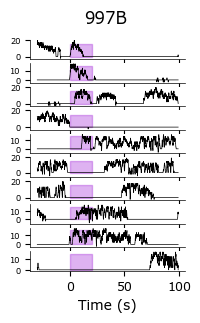

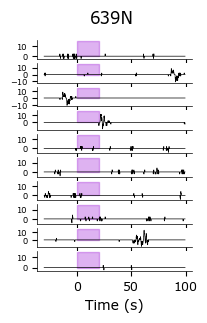

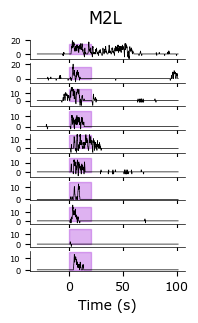

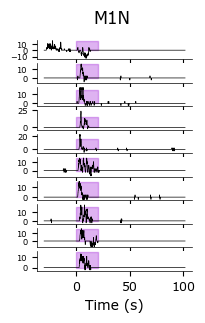

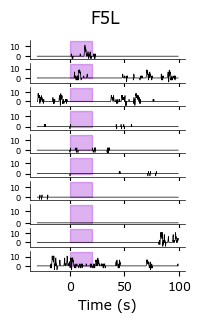

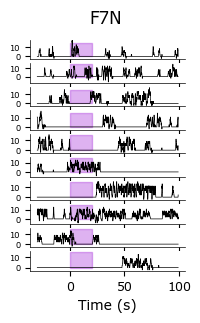

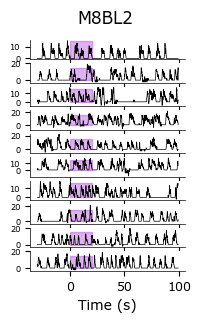

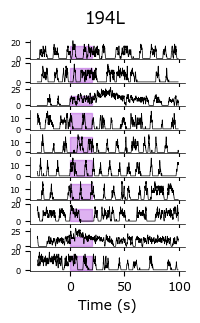

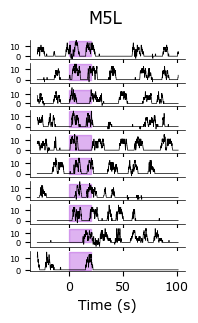

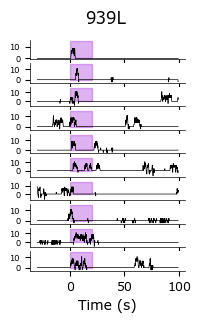

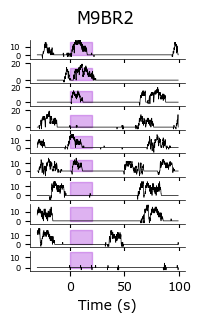

In [8]:
time = np.arange(0, len(vbar)) / 30 - seconds_pre
plt.rc('ytick', labelsize=6)               # y-axis tick label font size

for i in range(len(v_animal)):

    fig,ax=plt.subplots(nrows=10,figsize=(2,3))
    for j in range(10):
        v = v_animal[i][j]
        time = np.arange(0, len(v)) / 30 - seconds_pre

        ax[j].plot(time,v,color='k',lw=.5)
        ax[j].fill_betweenx(y=[0, 15], x1=0, x2=20, color='darkviolet', alpha=0.3, label='Tone On')
        # Only label the bottom subplot
        if j != 9:
            ax[j].set_xticklabels([])
        else:
            ax[j].set_xlabel('Time (s)')

         # Set axis line width
        for spine in ax[j].spines.values():
            spine.set_linewidth(0.5)
        # Set tick font sizes
        sb.despine(ax=ax[j])

    plt.suptitle(animals[i])
    plt.savefig(f'/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure5_Supp6/{animals[i]}_individual_trial_velocities.svg',transparent=True)